
Importing Libraries

In [ ]:
# Check the tensorflow version

import tensorflow as tf
tf.__version__

'2.15.0'

In [ ]:
import pandas as pd
import numpy as np
import os

import cv2

import albumentations as albu
from albumentations import Compose, ShiftScaleRotate, Resize
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

from sklearn.metrics import confusion_matrix
import itertools
from sklearn.metrics import classification_report

import shutil

import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
IMAGE_CHANNELS = 3

In [ ]:
os.listdir('/content/drive/MyDrive/RiceLeafsV1/train')

['BrownSpot', 'Healthy', 'LeafBlast', 'Hispa']

Helper Functions

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()


Loading Dataset

In [ ]:
import os
from google.colab import drive  # Mount Google Drive if necessary

# Assuming mounted drive (uncomment if needed)
# drive.mount('/content/drive')

data_dir = '/content/drive/MyDrive/RiceLeafsV1/train'

brown_spot_dir = os.path.join(data_dir, 'BrownSpot')
healthy_dir = os.path.join(data_dir, 'Healthy')
hispa_dir = os.path.join(data_dir, 'Hispa')
leaf_blast_dir = os.path.join(data_dir, 'LeafBlast')

# Create directories if they don't exist (optional)
# os.makedirs(brown_spot_dir, exist_ok=True)  # Uncomment if needed
# ... (similar for other directories)

brown_spot_list = os.listdir(brown_spot_dir)
healthy_list = os.listdir(healthy_dir)
hispa_list = os.listdir(hispa_dir)
leaf_blast_list = os.listdir(leaf_blast_dir)

print(len(brown_spot_list))
print(len(healthy_list))
print(len(hispa_list))
print(len(leaf_blast_list))



100
100
100
100


In [ ]:
# Create the train and val sets

df_brown_spot = pd.DataFrame(brown_spot_list, columns=['image'])
df_brown_spot['target'] = 'brown_spot'

df_healthy = pd.DataFrame(healthy_list, columns=['image'])
df_healthy['target'] = 'healthy'

df_hispa = pd.DataFrame(hispa_list, columns=['image'])
df_hispa['target'] = 'hispa'

df_leaf_blast = pd.DataFrame(leaf_blast_list, columns=['image'])
df_leaf_blast['target'] = 'leaf_blast'


# Create a val set for each class

# Sample 5 validation images from each class
df_brown_spot_val = df_brown_spot.sample(n=10, random_state=101)
df_healthy_val = df_healthy.sample(n=10, random_state=101)
df_hispa_val = df_hispa.sample(n=10, random_state=101)
df_leaf_blast_val = df_leaf_blast.sample(n=10, random_state=101)


print(len(df_brown_spot_val))
print(len(df_healthy_val))
print(len(df_hispa_val))
print(len(df_leaf_blast_val))

10
10
10
10


In [ ]:
# Create the train set for each class

# brown_spot
# get a list of val images
val_list = list(df_brown_spot_val['image'])
# filter out the val images
df_brown_spot_train = df_brown_spot[~df_brown_spot['image'].isin(val_list)] # ~ means notin

# healthy
# get a list of val images
val_list = list(df_healthy_val['image'])
# filter out the val images
df_healthy_train = df_healthy[~df_healthy['image'].isin(val_list)] # ~ means notin

# hispa
# get a list of val images
val_list = list(df_hispa_val['image'])
# filter out the val images
df_hispa_train = df_hispa[~df_hispa['image'].isin(val_list)] # ~ means notin


# leaf_blast
# get a list of val images
val_list = list(df_leaf_blast_val['image'])
# filter out the val images
df_leaf_blast_train = df_leaf_blast[~df_leaf_blast['image'].isin(val_list)] # ~ means notin

print(len(df_brown_spot_train))
print(len(df_healthy_train))
print(len(df_hispa_train))
print(len(df_leaf_blast_train))


90
90
90
90


In [ ]:
# Create df_data, df_train and df_val

df_data = pd.concat([ df_brown_spot, df_healthy,df_hispa, df_leaf_blast], axis=0).reset_index(drop=True)

df_train = \
pd.concat([ df_brown_spot_train, df_healthy_train, df_hispa_train, df_leaf_blast_train], axis=0).reset_index(drop=True)

df_val = \
pd.concat([ df_brown_spot_val, df_healthy_val, df_hispa_val, df_leaf_blast_val], axis=0).reset_index(drop=True)

df_data = shuffle(df_data)
df_train = shuffle(df_train)
df_val = shuffle(df_val)

print(df_data.shape)
print(df_train.shape)
print(df_val.shape)


(400, 2)
(360, 2)
(40, 2)


In [ ]:
df_data['target'].value_counts()


target
hispa         100
brown_spot    100
leaf_blast    100
healthy       100
Name: count, dtype: int64

In [ ]:
df_train['target'].value_counts()

target
leaf_blast    90
brown_spot    90
healthy       90
hispa         90
Name: count, dtype: int64

In [ ]:
df_val['target'].value_counts()

target
brown_spot    10
hispa         10
leaf_blast    10
healthy       10
Name: count, dtype: int64

Transform the target

In [ ]:
# combine val, train and test
val_len = len(df_val)
train_len = len(df_train)
df_combined =  pd.concat(objs=[df_val, df_train], axis=0).reset_index(drop=True)

# create the dummy variables
df_combined = pd.get_dummies(df_combined, columns=['target'])

# separate the train and val sets
df_val = df_combined[:val_len]
df_train = df_combined[val_len:]


print(df_train.shape)
print(df_val.shape)

(360, 5)
(40, 5)


In [ ]:
df_combined.head()

,image,target_brown_spot,target_healthy,target_hispa,target_leaf_blast
0,IMG_20190420_190359.jpg,True,False,False,False
1,IMG_20190419_141437.jpg,False,False,True,False
2,IMG_20190419_100814.jpg,False,False,False,True
3,IMG_20190419_140054.jpg,False,False,True,False
4,IMG_4831.jpg,True,False,False,False


In [ ]:
df_train.head()


,image,target_brown_spot,target_healthy,target_hispa,target_leaf_blast
40,IMG_20190419_110345.jpg,False,False,False,True
41,IMG_3181.jpg,True,False,False,False
42,IMG_20190419_133954.jpg,False,True,False,False
43,IMG_20190419_134450.jpg,False,True,False,False
44,IMG_5518.jpg,False,False,False,True


In [ ]:
df_val.head()

,image,target_brown_spot,target_healthy,target_hispa,target_leaf_blast
0,IMG_20190420_190359.jpg,True,False,False,False
1,IMG_20190419_141437.jpg,False,False,True,False
2,IMG_20190419_100814.jpg,False,False,False,True
3,IMG_20190419_140054.jpg,False,False,True,False
4,IMG_4831.jpg,True,False,False,False


Save the dataframes as compressed csv files

In [ ]:
# Assuming mounted drive (uncomment if necessary)
# from google.colab import drive
# drive.mount('/content/drive')

output_dir = '/content/drive/MyDrive/output'
os.makedirs(output_dir, exist_ok=True)  # Creates the directory if it doesn't exist

# Now you can save your CSV files:
df_combined.to_csv(os.path.join(output_dir, 'df_combined.csv.gz'), compression='gzip', index=False)
df_train.to_csv(os.path.join(output_dir, 'df_train.csv.gz'), compression='gzip', index=False)
df_val.to_csv(os.path.join(output_dir, 'df_val.csv.gz'), compression='gzip', index=False)


Move all images to the same folder

In [ ]:
# Assuming mounted drive (uncomment if necessary)
# from google.colab import drive
# drive.mount('/content/drive')

output_dir = '/content/drive/MyDrive/output'
image_dir = os.path.join(output_dir, 'image_dir')  # Combine paths for the full directory

# Create the directory 'image_dir' within 'output' if it doesn't exist
os.makedirs(image_dir, exist_ok=True)


In [ ]:
!ls /content/drive/MyDrive/output

df_combined.csv.gz  df_train.csv.gz  df_val.csv.gz  image_dir


In [ ]:

brown_spot_list = os.listdir(brown_spot_dir)
healthy_list = os.listdir(healthy_dir)
hispa_list = os.listdir(hispa_dir)
leaf_blast_list = os.listdir(leaf_blast_dir)

# Transfer the brown_spot images
for fname in brown_spot_list:

    path = '/content/drive/MyDrive/RiceLeafsV1/train/BrownSpot'

    # source path to image
    src = os.path.join(path, fname)
    # destination path to image
    dst = os.path.join(image_dir, fname)
    # copy the image from the source to the destination
    shutil.copyfile(src, dst)


# Transfer the healthy images
for fname in healthy_list:

    path = '/content/drive/MyDrive/RiceLeafsV1/train/Healthy'

    # source path to image
    src = os.path.join(path, fname)
    # destination path to image
    dst = os.path.join(image_dir, fname)
    # copy the image from the source to the destination
    shutil.copyfile(src, dst)


# Transfer the hispa images
for fname in hispa_list:

    path = '/content/drive/MyDrive/RiceLeafsV1/train/Hispa'

    # source path to image
    src = os.path.join(path, fname)
    # destination path to image
    dst = os.path.join(image_dir, fname)
    # copy the image from the source to the destination
    shutil.copyfile(src, dst)


# Transfer the leaf_blast images
for fname in leaf_blast_list:

    path = '/content/drive/MyDrive/RiceLeafsV1/train/LeafBlast'

    # source path to image
    src = os.path.join(path, fname)
    # destination path to image
    dst = os.path.join(image_dir, fname)
    # copy the image from the source to the destination
    shutil.copyfile(src, dst)




In [ ]:
# Check how many images are now in image_dir

path = '/content/drive/MyDrive/output/image_dir'
num_files = len(os.listdir(path))
print(f"Number of files in '{path}': {num_files}")


Number of files in '/content/drive/MyDrive/output/image_dir': 400



Display some images by class

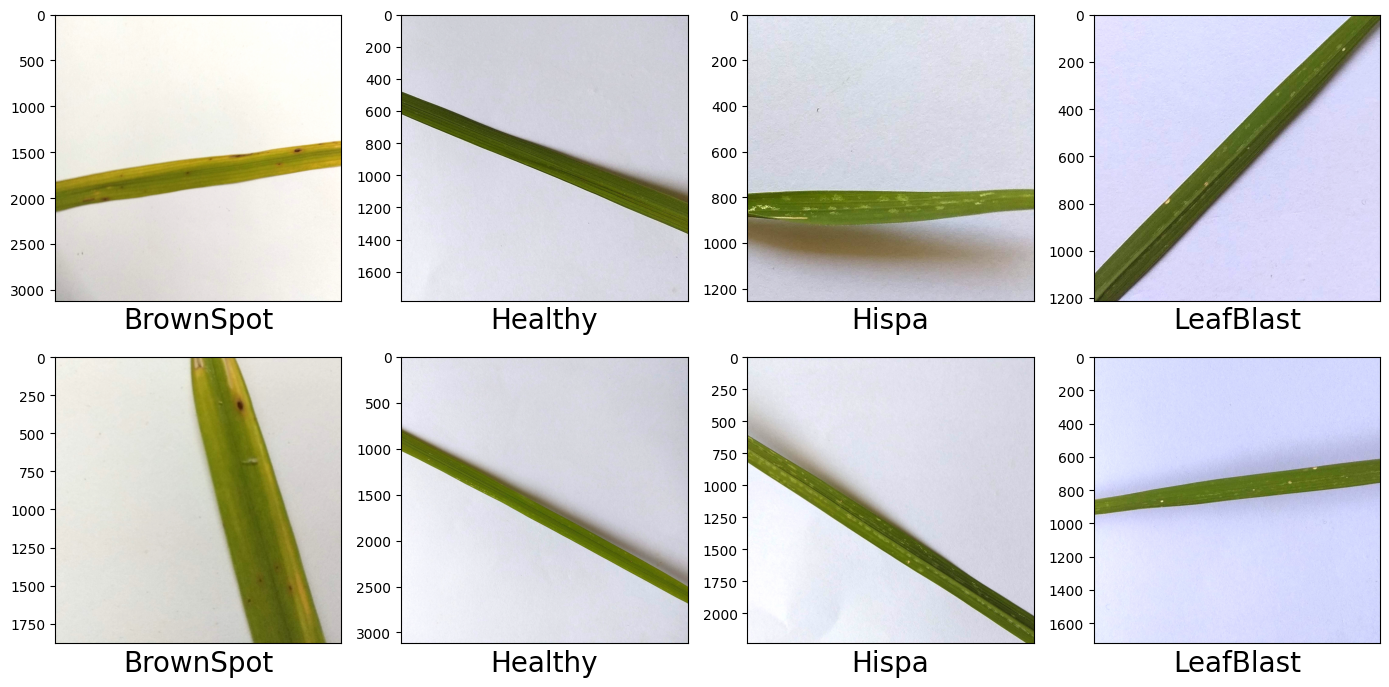

In [ ]:
import matplotlib.pyplot as plt

# Set up the canvas for the subplots
plt.figure(figsize=(14, 7))  # Adjust figsize for desired dimensions

# Define image data (replace with your actual data)
image_data = [
    ('BrownSpot', '/content/drive/MyDrive/RiceLeafsV1/train/BrownSpot/IMG_20190420_190157.jpg'),
    ('Healthy', '/content/drive/MyDrive/RiceLeafsV1/train/Healthy/IMG_20190419_134409.jpg'),
    ('Hispa', '/content/drive/MyDrive/RiceLeafsV1/train/Hispa/IMG_20190419_144411.jpg'),
    ('LeafBlast', '/content/drive/MyDrive/RiceLeafsV1/train/LeafBlast/IMG_20190419_110303.jpg'),
    ('BrownSpot', '/content/drive/MyDrive/RiceLeafsV1/train/BrownSpot/IMG_20190420_190524.jpg'),
    ('Healthy', '/content/drive/MyDrive/RiceLeafsV1/train/Healthy/IMG_20190419_133948.jpg'),
    ('Hispa', '/content/drive/MyDrive/RiceLeafsV1/train/Hispa/IMG_20190419_140219.jpg'),
    ('LeafBlast', '/content/drive/MyDrive/RiceLeafsV1/train/LeafBlast/IMG_20190419_110347.jpg')
]

# Loop through image data and display in subplots
rows, cols = 2, 4  # 2 rows, 4 columns
for i, (label, path) in enumerate(image_data):
    plt.subplot(rows, cols, i + 1)  # Start indexing from 1 for subplots
    image = plt.imread(path)
    plt.imshow(image)
    plt.xlabel(label, fontsize=20)
    plt.xticks([])  # Turn off x-axis ticks for better layout

# Adjust layout (optional)
plt.tight_layout()

# Display the plot
plt.show()


Set up and test the Augmentations

In [ ]:
import albumentations as albu


def augment_image(augmentation, image):

    """
    Uses the Albumentations library.

    Inputs:
    1. augmentation - this is the instance of type of augmentation to do
    e.g. aug_type = HorizontalFlip(p=1)
    # p=1 is the probability of the transform being executed.

    2. image - image with shape (h,w)

    Output:
    Augmented image as a numpy array.

    """
    # get the transform as a dict
    aug_image_dict =  augmentation(image=image)
    # retrieve the augmented matrix of the image
    image_matrix = aug_image_dict['image']


    return image_matrix

In [ ]:
import albumentations as albu

aug_types = albu.Compose([
    albu.HorizontalFlip(),
    albu.OneOf([
        albu.HorizontalFlip(),
        albu.VerticalFlip(),
    ], p=0.8),
    albu.OneOf([
        albu.augmentations.RandomBrightnessContrast(),  # Use this for older versions
        albu.RandomGamma(),
        # albu.RandomBrightness(),  # Not available in older versions
    ], p=0.3),
    albu.ShiftScaleRotate()
])


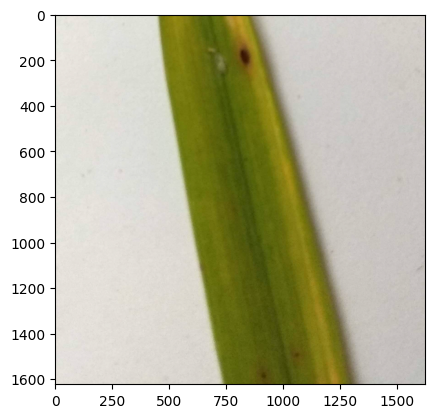

In [ ]:
import os
import matplotlib.pyplot as plt

# Get an image to test transformations

# Get the path to the image directory
path = '/content/drive/MyDrive/output/image_dir'

# Check if the directory exists (optional)
if not os.path.exists(path):
  print("Error: Directory", path, "does not exist.")
  exit()

# Loop through all images in the directory
for fname in os.listdir(path):
  image_path = os.path.join(path, fname)
  image = plt.imread(image_path)
  plt.imshow(image)
  plt.show()  # Add plt.show() to display each image
  break  # Uncomment to only process the first image


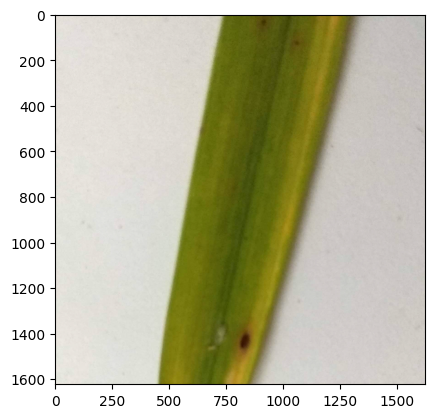

In [ ]:
# Test the transformation setup.
# The image will be different each time this cell is run.

aug_image = augment_image(aug_types, image)

plt.imshow(aug_image)

Build the Data Generators

[ 1 ] Train Generator

In [ ]:
df_train.head()

,image,target_brown_spot,target_healthy,target_hispa,target_leaf_blast
40,IMG_20190419_110345.jpg,False,False,False,True
41,IMG_3181.jpg,True,False,False,False
42,IMG_20190419_133954.jpg,False,True,False,False
43,IMG_20190419_134450.jpg,False,True,False,False
44,IMG_5518.jpg,False,False,False,True


In [ ]:
def train_generator(batch_size=8):
    output_path = '/content/drive/MyDrive/output/df_train.csv.gz'

    while True:
        # load the data in chunks (batches)
        for df in pd.read_csv(output_path, chunksize=batch_size):

            # get the list of images
            image_id_list = list(df['image'])

            # Create empty X matrix - 3 channels
            X_train = np.zeros((len(df), IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS), dtype=np.uint8)

            # Create X_train
            for i in range(0, len(image_id_list)):

                # get the image and mask
                image_id = image_id_list[i]

                # set the path to the image
                path = '/content/drive/MyDrive/output/image_dir/' + image_id

                # read the image
                image = cv2.imread(path)

                # convert to from BGR to RGB
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                # resize the image
                image = cv2.resize(image, (IMAGE_HEIGHT, IMAGE_WIDTH))

                # Create y_train
                cols = ['target_brown_spot', 'target_healthy', 'target_hispa', 'target_leaf_blast']
                y_train = df[cols]
                y_train = np.asarray(y_train)

                # change the shape to (batch_size, 1)
                #y_train = y_train.reshape((-1, 1)) # -1 tells numpy to automatically detect the batch size

                # Augment the image and mask
                aug_image = augment_image(aug_types, image)

                # insert the image into X_train
                X_train[i] = aug_image

            # Normalize the images
            X_train = X_train/255

            yield X_train, y_train



# Test the generator

# initialize
train_gen = train_generator(batch_size=8)

# run the generator
X_train, y_train = next(train_gen)

print(X_train.shape)
print(y_train.shape)


(8, 224, 224, 3)
(8, 4)


In [ ]:
y_train

array([[False, False, False,  True],
       [ True, False, False, False],
       [False,  True, False, False],
       [False,  True, False, False],
       [False, False, False,  True],
       [False,  True, False, False],
       [ True, False, False, False],
       [ True, False, False, False]])

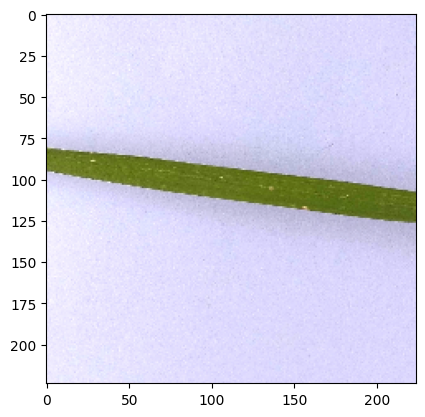

In [ ]:
# Print the first image in X_train
# Remember that train images have been augmented.

image = X_train[0,:,:,:]
plt.imshow(image)

[ 2 ] Val Generator

In [ ]:
def val_generator(batch_size=5):

  while True:
    val_path = '/content/drive/MyDrive/output/df_val.csv.gz'

    # Load the data in chunks (batches)
    for df in pd.read_csv(val_path, chunksize=batch_size):

      # Get the list of images
      image_id_list = list(df['image'])

      # Create empty X matrix - 3 channels
      X_val = np.zeros((len(df), IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS), dtype=np.uint8)

      # Create X_val
      # ===============
      for i in range(0, len(image_id_list)):

        # Get the image and mask
        image_id = image_id_list[i]

        # Set the path to the image (assuming 'image_dir/' is the correct directory)
        path = '/content/drive/MyDrive/output/image_dir/' + image_id

        # Print the image path for debugging
        print(path)

        try:
          # Read the image using OpenCV (handle potential errors)
          image = cv2.imread(path)

          if image is None:
            print(f"Error reading image: {path}")
            continue  # Skip this image if reading failed

          # Convert from BGR to RGB
          image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

          # Resize the image
          image = cv2.resize(image, (IMAGE_HEIGHT, IMAGE_WIDTH))

          # Insert the image into X_val
          X_val[i] = image

        except Exception as e:  # Catch generic exceptions for broader error handling
          print(f"Error processing image {path}: {e}")
          continue  # Skip this image if an error occurs

      # Create y_val
      # ===============
      cols = ['target_brown_spot', 'target_healthy', 'target_hispa', 'target_leaf_blast']
      y_val = df[cols]
      y_val = np.asarray(y_val)

      # Change the shape to (batch_size, 1) (optional, depending on your needs)
      # y_val = y_val.reshape((-1, 1))  # -1 tells numpy to automatically detect the batch size

      # Normalize the images
      X_val = X_val / 255

      yield X_val, y_val

# Test the generator

# Initialize
val_gen = val_generator(batch_size=5)

# Run the generator
X_val, y_val = next(val_gen)

print(X_val.shape)
print(y_val.shape)


/content/drive/MyDrive/output/image_dir/IMG_20190420_190359.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_141437.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_100814.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_140054.jpg
/content/drive/MyDrive/output/image_dir/IMG_4831.jpg
(5, 224, 224, 3)
(5, 4)


In [ ]:
y_val

array([[ True, False, False, False],
       [False, False,  True, False],
       [False, False, False,  True],
       [False, False,  True, False],
       [ True, False, False, False]])

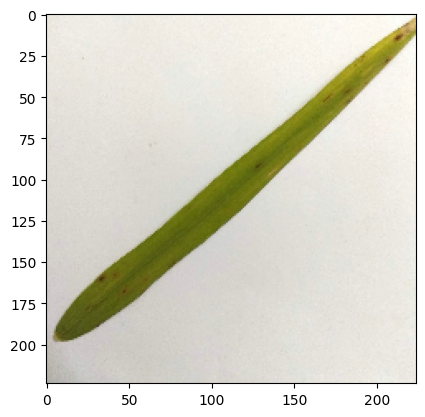

In [ ]:
# print the image from X_val
image = X_val[0,:,:,:]
plt.imshow(image)


[ 3 ] Test Generator

In [ ]:
def test_generator(batch_size=1):

    while True:
      test_path = '/content/drive/MyDrive/output/df_val.csv.gz'

        # load the data in chunks (batches)
      for df in pd.read_csv(test_path, chunksize=batch_size):

          # get the list of images
          image_id_list = list(df['image'])

          # Create empty X matrix - 3 channels
          X_test = np.zeros((len(df), IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS), dtype=np.uint8)




          # Create X_test
           #================

      for i in range(0, len(image_id_list)):


         # get the image and mask
         image_id = image_id_list[i]


         # set the path to the image
         path = '/content/drive/MyDrive/output/image_dir/' + image_id

         # read the image
         image = cv2.imread(path)

         # convert to from BGR to RGB
         image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

         # resize the image
         image = cv2.resize(image, (IMAGE_HEIGHT, IMAGE_WIDTH))

         # insert the image into X_train
         X_test[i] = image



         # Normalize the images
         X_test = X_test/255

         yield X_test

In [ ]:
# Test the generator

# initialize
test_gen = test_generator(batch_size=1)

# run the generator
X_test = next(test_gen)

print(X_test.shape)

(1, 224, 224, 3)


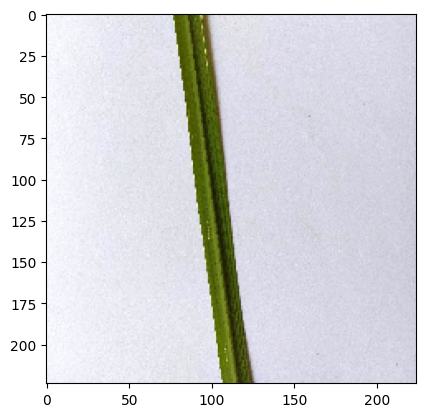

In [ ]:
# print the image from X_test

image = X_test[0,:,:,:]
plt.imshow(image)



Model Architecture

In [ ]:
from tensorflow import keras

# Access specific components
from keras.models import Model, load_model
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
# ... and so on


In [ ]:
from tensorflow.keras.applications.mobilenet import MobileNet

model = MobileNet(weights='imagenet')

# Exclude the last 2 layers of the above model.
x = model.layers[-2].output

# Create a new dense layer for predictions
# 4 corresponds to the number of classes
predictions = Dense(4, activation='softmax')(x)

# inputs=model.input selects the input layer, outputs=predictions refers to the
# dense layer we created above.

model = Model(inputs=model.input, outputs=predictions)

model.summary()

17225924/17225924 [==============================] - 0s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizati  (None, 112, 112, 32)      128       
 on)                                                             
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D  (None, 112, 112, 32)      288       
 )                                                               
                                                              

Train the Model

In [ ]:
TRAIN_BATCH_SIZE = 8
VAL_BATCH_SIZE = 5

num_train_samples = len(df_train)
num_val_samples = len(df_val)
train_batch_size = TRAIN_BATCH_SIZE
val_batch_size = VAL_BATCH_SIZE

# determine numtrain steps
train_steps = np.ceil(num_train_samples / train_batch_size)
# determine num val steps
val_steps = np.ceil(num_val_samples / val_batch_size)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger  # Import both
from tensorflow.keras.utils import to_categorical  # Import to_categorical

# Initialize the generators
train_gen = train_generator(batch_size=TRAIN_BATCH_SIZE)
val_gen = val_generator(batch_size=VAL_BATCH_SIZE)


model.compile(
    Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

filepath = "/content/drive/MyDrive/model/modelV1.keras"



#earlystopper = EarlyStopping(patience=10, verbose=1)

checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1,
                             save_best_only=True, mode='max')

#reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                                   #verbose=1, mode='min')


fpath = "/content/drive/MyDrive/output/"
train_log = os.path.join(fpath, train_log.csv)
csv_logger = CSVLogger(filename=log_fname,
                       separator=',',
                       append=False)

callbacks_list = [checkpoint, csv_logger]

# Print data shapes for debugging
train_x, train_y = next(train_gen)
print("Train data shape:", train_x.shape)
print("Train labels shape:", train_y.shape)


if len(set(train_y.flatten())) == len(train_y):  # Check if labels need encoding
    train_y = to_categorical(train_y)  # One-hot encode labels if necessary

train_steps = int(train_steps)  # Convert to integer (truncate decimals)
for _ in range(train_steps):  # Loop for training steps
    train_x, train_y = next(train_gen)  # Get next training batch
    model.train_on_batch(train_x, train_y)


history = model.fit(train_gen, steps_per_epoch=train_steps, epochs=100,
                    validation_data=val_gen, validation_steps=val_steps,
                    verbose=1, callbacks=callbacks_list)


filepath = "/content/drive/MyDrive/model/modelV1.keras"
model.save(filepath)

Train data shape: (8, 224, 224, 3)
Train labels shape: (8, 4)
Epoch 1/100
45/45 [==============================] - ETA: 0s - loss: 1.3902 - accuracy: 0.6722/content/drive/MyDrive/output/image_dir/IMG_20190420_190359.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_141437.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_100814.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_140054.jpg
/content/drive/MyDrive/output/image_dir/IMG_4831.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_130033.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_110154.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_131458.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_133849.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_140138.jpg
/content/drive/MyDrive/output/image_dir/IMG_5508.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_124344.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_130113.jpg
/content/drive/MyDrive/output/imag

Evaluate the model on the val set

In [ ]:
# get the metric names so we can use evaulate_generator
model.metrics_names


['loss', 'accuracy']

In [ ]:
model.load_weights('/content/drive/MyDrive/model/modelV1.keras')

val_gen = val_generator(batch_size=1)

val_loss, val_acc = \
model.evaluate_generator(val_gen,
                        steps=len(df_val))

print('val_loss:', val_loss)
print('val_acc:', val_acc)

<ipython-input-50-5b2d90b77997>:6: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  model.evaluate_generator(val_gen,


/content/drive/MyDrive/output/image_dir/IMG_20190420_190359.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_141437.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_100814.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_140054.jpg
/content/drive/MyDrive/output/image_dir/IMG_4831.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_130033.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_110154.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_131458.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_133849.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_140138.jpg
/content/drive/MyDrive/output/image_dir/IMG_5508.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_124344.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_130113.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_123656.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190420_190225.jpg
/content/drive/MyDrive/output/image_dir/IMG_20190419_134526.jp


Plot the training curves

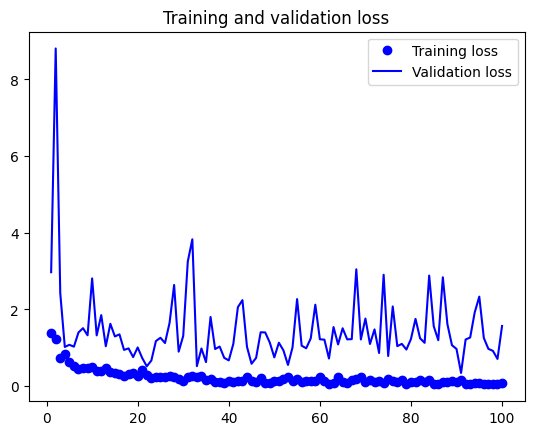

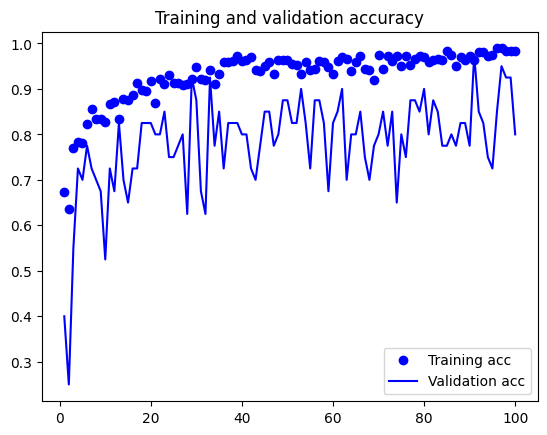

<Figure size 640x480 with 0 Axes>

In [ ]:
# display the loss and accuracy curves

import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.figure()


plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()

plt.show()

Make a prediction on the val set

In [ ]:
test_gen = test_generator(batch_size=1)

preds = model.predict_generator(test_gen, steps=len(df_val), verbose=1)

<ipython-input-52-fa6b6bac86c9>:3: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  preds = model.predict_generator(test_gen, steps=len(df_val), verbose=1)


40/40 [==============================] - 18s 433ms/step


In [ ]:
# get y_pred as index values

y_pred = np.argmax(preds, axis=1)

y_pred


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
# get y_true as index values

cols = ['target_brown_spot', 'target_healthy', 'target_hispa', 'target_leaf_blast']
y_true = df_val[cols]
y_true = np.asarray(y_true)

y_true = np.argmax(y_true, axis=1)

y_true


array([0, 2, 3, 2, 0, 1, 3, 2, 1, 2, 3, 1, 1, 1, 0, 1, 0, 3, 2, 1, 2, 1,
       1, 3, 1, 0, 3, 0, 0, 0, 0, 2, 3, 3, 0, 2, 3, 3, 2, 2])

In [ ]:
# Compare y_true and y_pred

print(y_pred)
print(y_true)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2]
[0 2 3 2 0 1 3 2 1 2 3 1 1 1 0 1 0 3 2 1 2 1 1 3 1 0 3 0 0 0 0 2 3 3 0 2 3
 3 2 2]


Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import itertools

cm = confusion_matrix(y_true, y_pred)

Confusion matrix, without normalization
[[ 0  0 10  0]
 [ 0  0 10  0]
 [ 0  0 10  0]
 [ 0  0 10  0]]


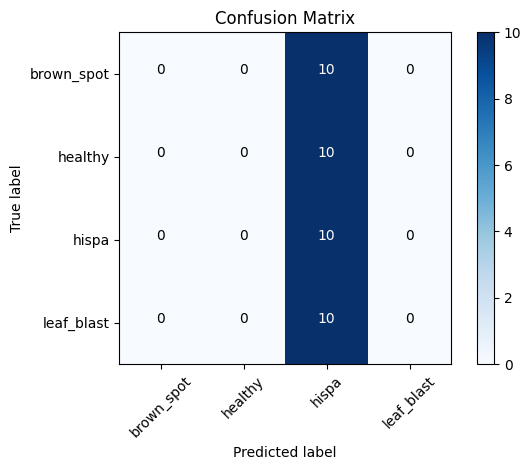

In [ ]:


cm_plot_labels = ['brown_spot', 'healthy', 'hispa', 'leaf_blast']

plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix')


Classification Report

In [ ]:
from sklearn.metrics import classification_report

# Generate a classification report
report = classification_report(y_true, y_pred, target_names=['brown_spot', 'healthy', 'hispa', 'leaf_blast'])

print(report)

              precision    recall  f1-score   support

  brown_spot       0.00      0.00      0.00        10
     healthy       0.00      0.00      0.00        10
       hispa       0.25      1.00      0.40        10
  leaf_blast       0.00      0.00      0.00        10

    accuracy                           0.25        40
   macro avg       0.06      0.25      0.10        40
weighted avg       0.06      0.25      0.10        40



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Convert the Model to Tensorflow.js